In [1]:
from torchvision import datasets, transforms, models
import torch.utils.data as data

import matplotlib.pyplot as plt
from torch import nn
import torch.optim as optim
import torch
from tqdm.notebook import trange, tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ParallelCNN(nn.Module):
    def __init__(self, num_classes):
        super(ParallelCNN, self).__init__()

        # First branch
        self.branch1_conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.branch1_conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.branch1_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second branch
        self.branch2_conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.branch2_conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.branch2_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Global Average Pooling to reduce the output size
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected layer (reduced size)
        self.fc1 = nn.Linear(32 * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # First branch forward pass
        branch1 = F.relu(self.branch1_conv1(x))
        branch1 = F.relu(self.branch1_conv2(branch1))
        branch1 = self.branch1_pool(branch1)

        # Second branch forward pass
        branch2 = F.relu(self.branch2_conv1(x))
        branch2 = F.relu(self.branch2_conv2(branch2))
        branch2 = self.branch2_pool(branch2)

        # Concatenate along the channel dimension
        combined = torch.cat((branch1, branch2), dim=1)

        # Global average pooling
        combined = self.global_avg_pool(combined)
        combined = combined.view(combined.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x



In [14]:
# Define any transformations you want (similar to how you use in CIFAR10)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 32x32 like CIFAR if necessary
    transforms.ToTensor(),        # Convert images to tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize based on your dataset
])

dataset = datasets.ImageFolder(root=r'..\Dataset\Train', transform=transform)

# Calculate the lengths for training and testing splits (80% - 20%)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset
train_dataset, test_dataset =  data.random_split(dataset, [train_size, test_size])

# Create DataLoaders for training and testing datasets
trainloader =  data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
testloader =  data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Modify the final layer to match the number of classes in your dataset
num_classes = 12
model = ParallelCNN(num_classes)

# Check if a GPU is available and move the model to GPU if possible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
for inputs, labels in trainloader:
    print("Labels:", labels)  # Ensure these are valid indices
    # Proceed with training...

Labels: tensor([ 6,  3,  6,  5,  2,  1,  2,  6,  3,  8,  6,  2,  4, 11,  3,  4,  0,  4,
         8,  6,  2, 11,  1,  9,  1, 11,  6, 11,  2,  0,  5,  6,  1,  6,  2,  1,
         2,  0,  6, 11,  6,  2,  8,  0,  6,  3,  9,  6, 11,  8,  4,  0,  6,  6,
        11,  0,  3,  9,  6,  8, 10,  4,  2,  8])
Labels: tensor([ 0,  0,  2,  6,  7,  5,  4,  3,  2,  2,  1,  6,  6,  3,  9,  0,  0,  6,
         2,  4,  2,  8, 10,  0,  0,  2,  6,  2,  1,  1, 11,  6,  4,  1,  5,  0,
         0,  1, 10, 10,  2,  2,  1,  2,  8,  5,  1,  0,  4,  0,  2,  5,  0,  1,
         5,  1,  5,  0,  1,  1, 10,  6,  2,  0])
Labels: tensor([ 1,  8,  8,  2, 11, 10, 11,  7,  2,  6,  5,  4, 11,  2,  2,  0,  6,  0,
         8,  5,  1,  1,  0,  2,  8, 11, 11,  1,  2,  2,  1,  2, 11,  4,  5,  8,
         1,  2,  6,  8,  6,  0,  5,  0,  2,  3,  1,  2,  0,  0,  0,  2,  3,  2,
         0,  5,  8,  2,  6,  2,  6,  5, 11,  7])
Labels: tensor([ 2,  0,  1,  0,  6,  2,  8,  2,  5,  6,  6,  2,  2,  0,  1,  1,  9,  0,
         1,  5,  6,  

In [44]:
print(f"Labels: {labels}")
print(num_classes-1)

Labels: tensor([ 6,  1,  7,  0,  6,  1,  2,  0,  9,  8, 10,  4,  2,  5,  0,  9,  0,  6,
         8,  2, 10,  2,  8,  6,  1,  4,  4,  0,  4,  5,  6,  0,  8,  8,  0,  2,
         8, 10,  8,  8,  5,  2,  4,  8,  0,  1,  7,  1,  8,  6, 10, 10,  6,  1,
         6,  6,  1,  2, 11,  3,  8,  0,  1,  0])
11


In [12]:
inputs.to(device)
model.to(device)
outputs = model(inputs)
print("Output shape:", outputs.shape)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [16]:
def count_parameters(NN):
    return sum([p.numel() for p in NN.parameters() if p.requires_grad==True])

print(f"trainable parameters: {count_parameters(model)}")


trainable parameters: 15116


Train+plot

Epoch 1/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 1, Batch 100] loss: 1.623
Accuracy after epoch 1: 43.47%


Epoch 2/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 2, Batch 100] loss: 1.579
Accuracy after epoch 2: 45.66%


Epoch 3/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 3, Batch 100] loss: 1.566
Accuracy after epoch 3: 46.19%


Epoch 4/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 4, Batch 100] loss: 1.546
Accuracy after epoch 4: 44.83%


Epoch 5/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 5, Batch 100] loss: 1.526
Accuracy after epoch 5: 46.92%


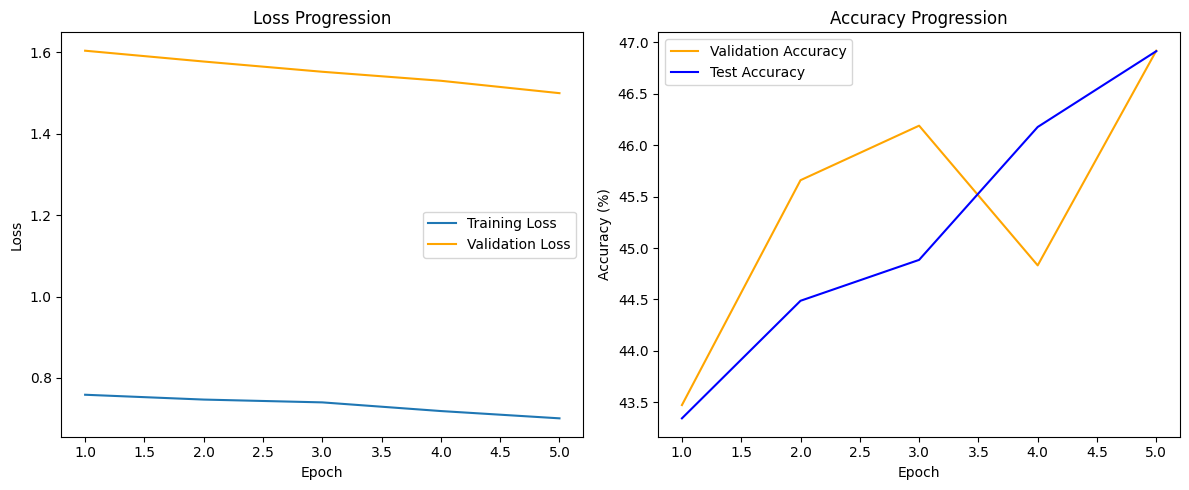

Epoch 6/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 6, Batch 100] loss: 1.500
Accuracy after epoch 6: 45.99%


Epoch 7/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 7, Batch 100] loss: 1.496
Accuracy after epoch 7: 46.59%


Epoch 8/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 8, Batch 100] loss: 1.447
Accuracy after epoch 8: 48.48%


Epoch 9/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 9, Batch 100] loss: 1.434
Accuracy after epoch 9: 49.17%


Epoch 10/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 10, Batch 100] loss: 1.421
Accuracy after epoch 10: 49.01%


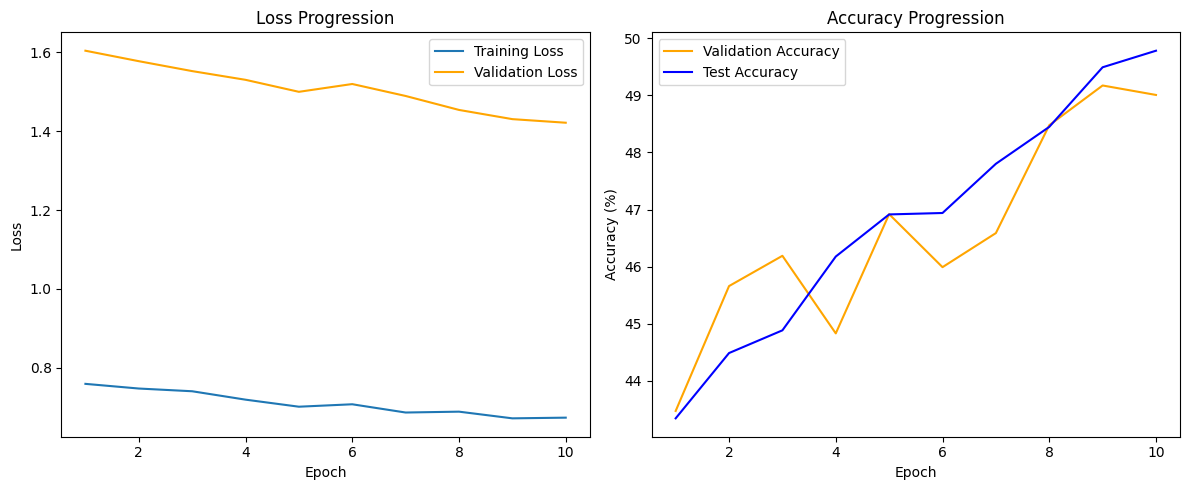

Epoch 11/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 11, Batch 100] loss: 1.396
Accuracy after epoch 11: 49.54%


Epoch 12/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 12, Batch 100] loss: 1.393
Accuracy after epoch 12: 50.89%


Epoch 13/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 13, Batch 100] loss: 1.379
Accuracy after epoch 13: 49.37%


Epoch 14/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 14, Batch 100] loss: 1.353
Accuracy after epoch 14: 50.07%


Epoch 15/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 15, Batch 100] loss: 1.344
Accuracy after epoch 15: 52.02%


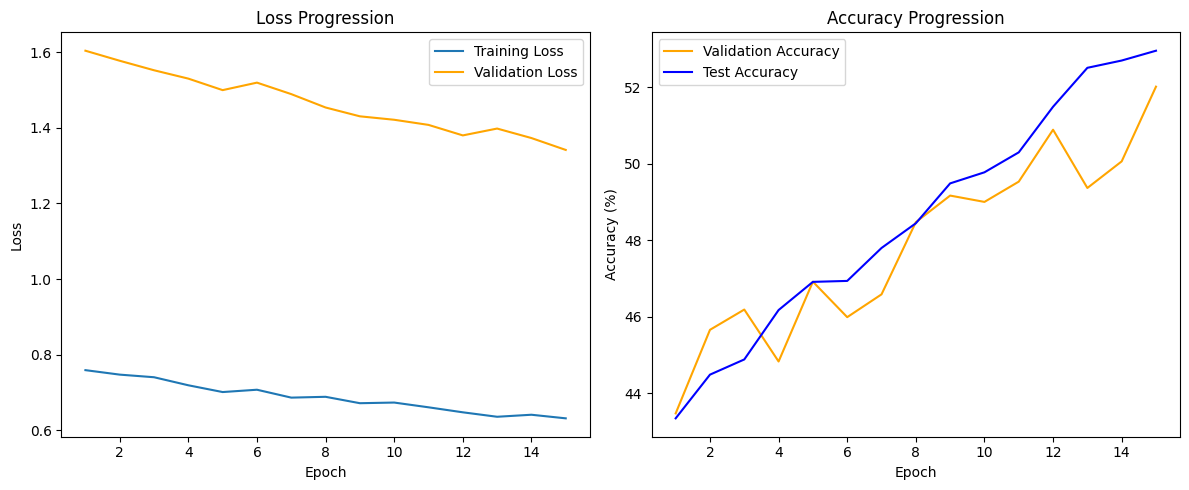

Epoch 16/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 16, Batch 100] loss: 1.332
Accuracy after epoch 16: 53.08%


Epoch 17/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 17, Batch 100] loss: 1.314
Accuracy after epoch 17: 51.59%


Epoch 18/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 18, Batch 100] loss: 1.286
Accuracy after epoch 18: 52.58%


Epoch 19/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 19, Batch 100] loss: 1.300
Accuracy after epoch 19: 53.78%


Epoch 20/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 20, Batch 100] loss: 1.265
Accuracy after epoch 20: 54.08%


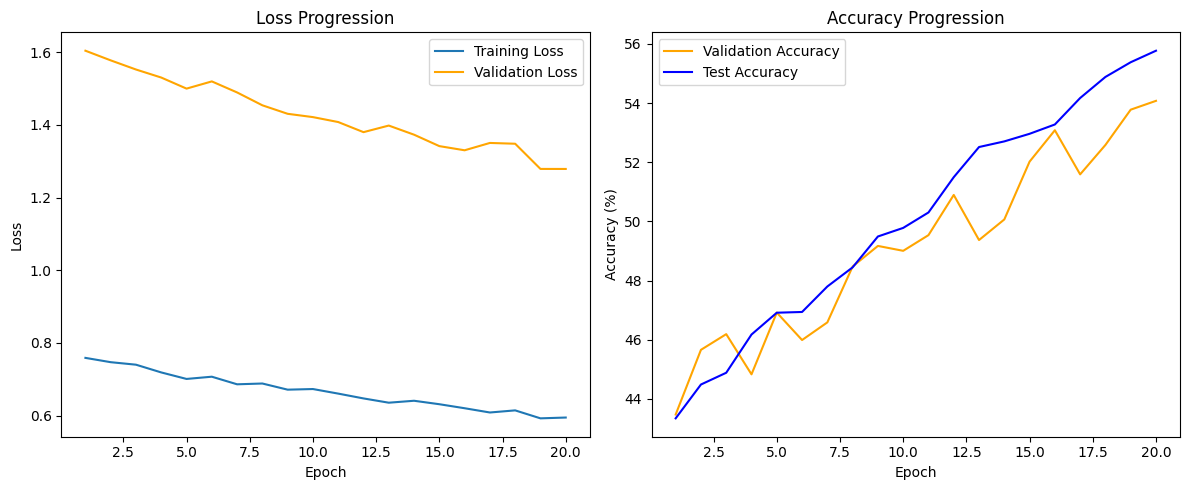

Epoch 21/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 21, Batch 100] loss: 1.242
Accuracy after epoch 21: 54.21%


Epoch 22/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 22, Batch 100] loss: 1.225
Accuracy after epoch 22: 55.40%


Epoch 23/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 23, Batch 100] loss: 1.222
Accuracy after epoch 23: 55.53%


Epoch 24/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 24, Batch 100] loss: 1.233
Accuracy after epoch 24: 54.71%


Epoch 25/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 25, Batch 100] loss: 1.210
Accuracy after epoch 25: 55.70%


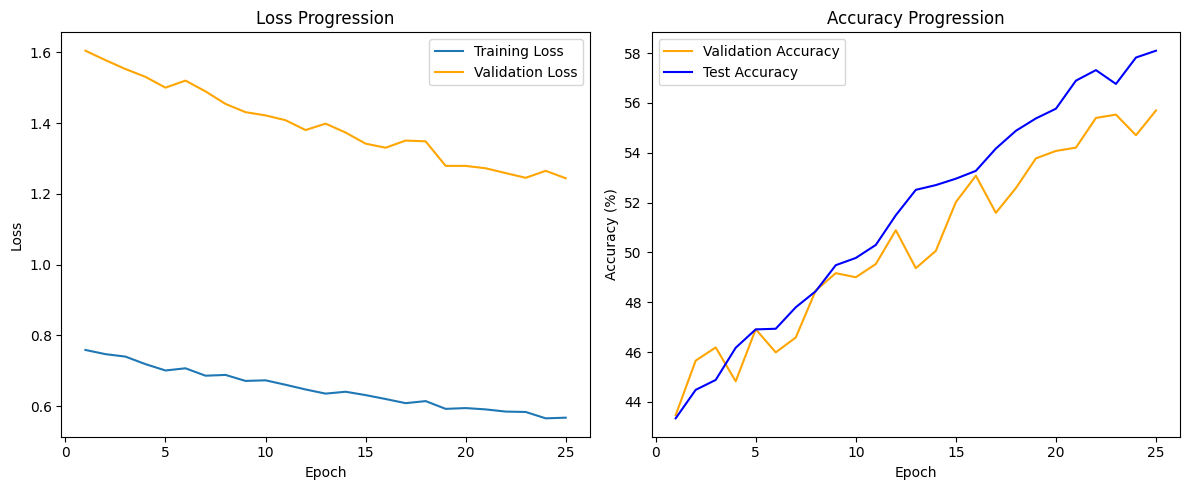

Epoch 26/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 26, Batch 100] loss: 1.215
Accuracy after epoch 26: 55.90%


Epoch 27/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 27, Batch 100] loss: 1.202
Accuracy after epoch 27: 55.83%


Epoch 28/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 28, Batch 100] loss: 1.182
Accuracy after epoch 28: 57.06%


Epoch 29/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 29, Batch 100] loss: 1.184
Accuracy after epoch 29: 57.22%


Epoch 30/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 30, Batch 100] loss: 1.154
Accuracy after epoch 30: 56.89%


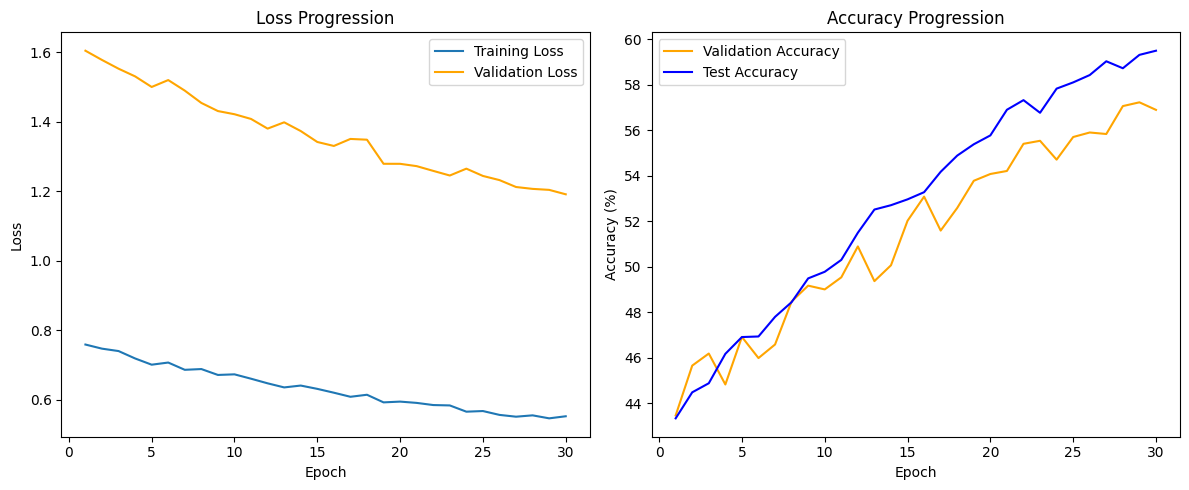

Epoch 31/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 31, Batch 100] loss: 1.166
Accuracy after epoch 31: 57.79%


Epoch 32/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 32, Batch 100] loss: 1.149
Accuracy after epoch 32: 58.65%


Epoch 33/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 33, Batch 100] loss: 1.134
Accuracy after epoch 33: 57.19%


Epoch 34/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 34, Batch 100] loss: 1.138
Accuracy after epoch 34: 59.15%


Epoch 35/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 35, Batch 100] loss: 1.092
Accuracy after epoch 35: 57.16%


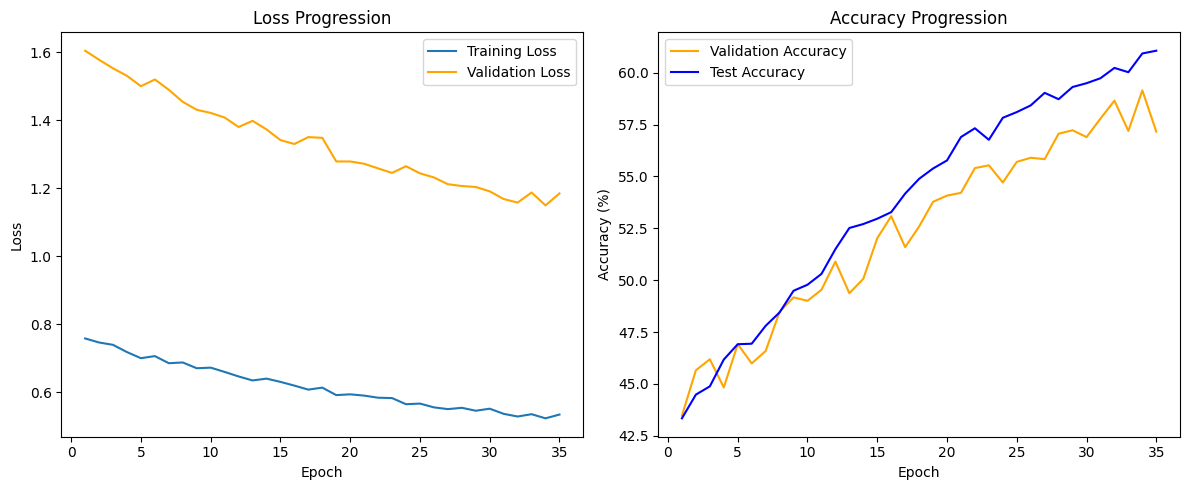

Epoch 36/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 36, Batch 100] loss: 1.129
Accuracy after epoch 36: 60.64%


Epoch 37/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 37, Batch 100] loss: 1.091
Accuracy after epoch 37: 59.24%


Epoch 38/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 38, Batch 100] loss: 1.089
Accuracy after epoch 38: 59.28%


Epoch 39/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 39, Batch 100] loss: 1.091
Accuracy after epoch 39: 59.28%


Epoch 40/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 40, Batch 100] loss: 1.084
Accuracy after epoch 40: 61.00%


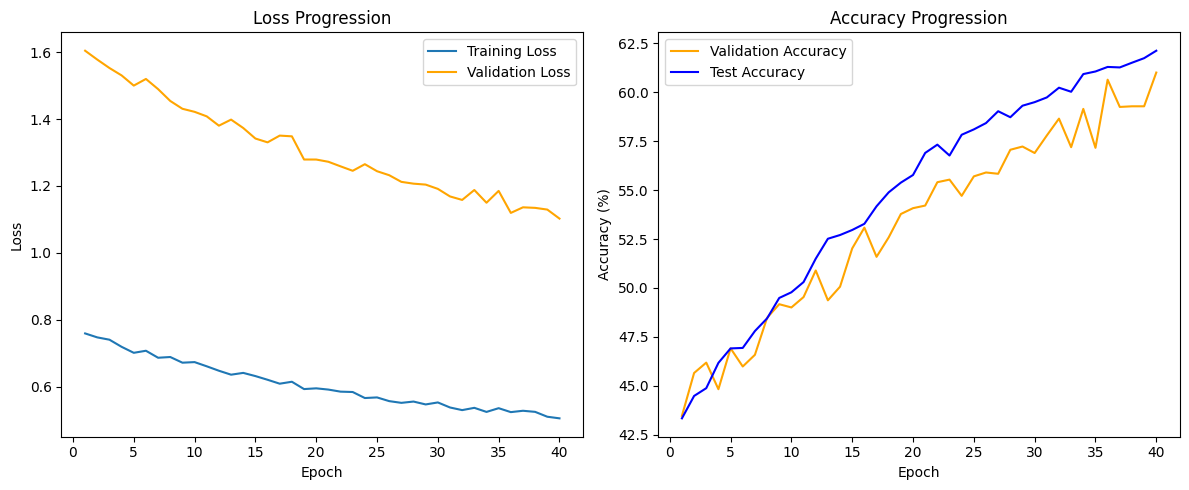

Epoch 41/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 41, Batch 100] loss: 1.066
Accuracy after epoch 41: 61.13%


Epoch 42/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 42, Batch 100] loss: 1.079
Accuracy after epoch 42: 60.11%


Epoch 43/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 43, Batch 100] loss: 1.059
Accuracy after epoch 43: 61.80%


Epoch 44/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 44, Batch 100] loss: 1.049
Accuracy after epoch 44: 61.83%


Epoch 45/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 45, Batch 100] loss: 1.037
Accuracy after epoch 45: 61.80%


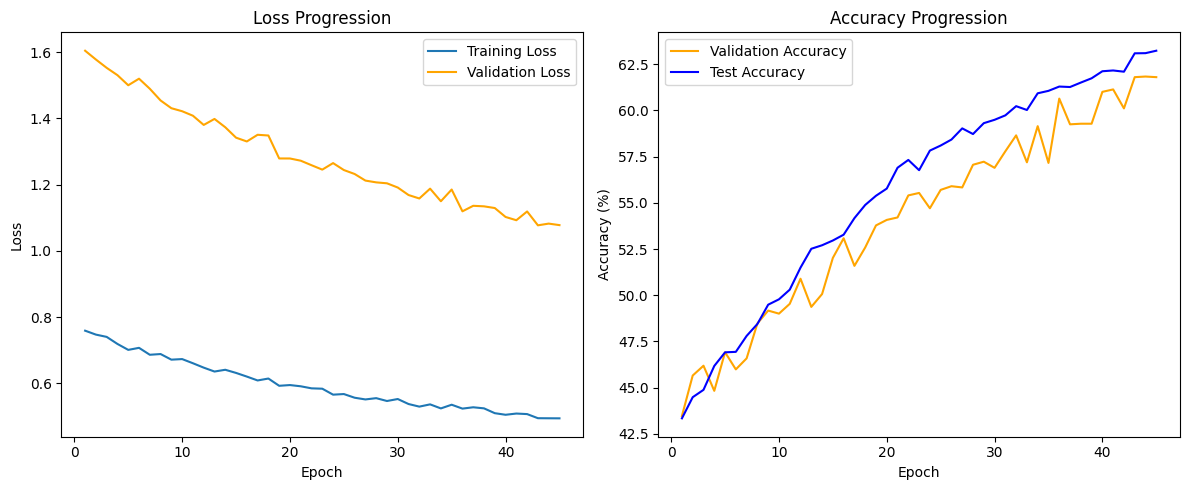

Epoch 46/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 46, Batch 100] loss: 1.041
Accuracy after epoch 46: 62.56%


Epoch 47/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 47, Batch 100] loss: 1.037
Accuracy after epoch 47: 62.86%


Epoch 48/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 48, Batch 100] loss: 1.024
Accuracy after epoch 48: 63.25%


Epoch 49/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 49, Batch 100] loss: 1.008
Accuracy after epoch 49: 61.00%


Epoch 50/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 50, Batch 100] loss: 0.986
Accuracy after epoch 50: 63.12%


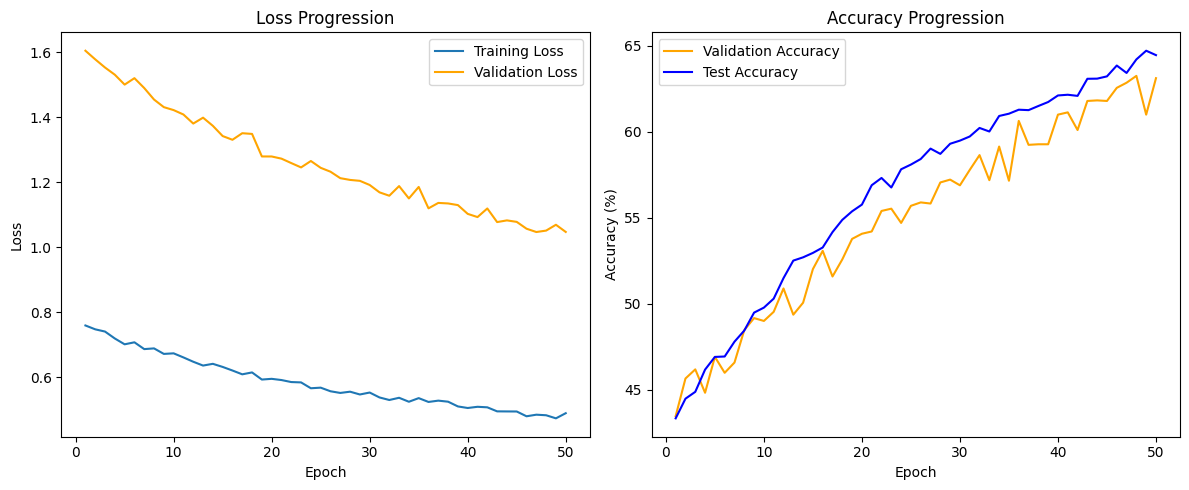

Epoch 51/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 51, Batch 100] loss: 1.013
Accuracy after epoch 51: 63.19%


Epoch 52/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 52, Batch 100] loss: 1.005
Accuracy after epoch 52: 64.05%


Epoch 53/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 53, Batch 100] loss: 0.989
Accuracy after epoch 53: 64.12%


Epoch 54/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 54, Batch 100] loss: 0.992
Accuracy after epoch 54: 64.48%


Epoch 55/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 55, Batch 100] loss: 0.974
Accuracy after epoch 55: 62.92%


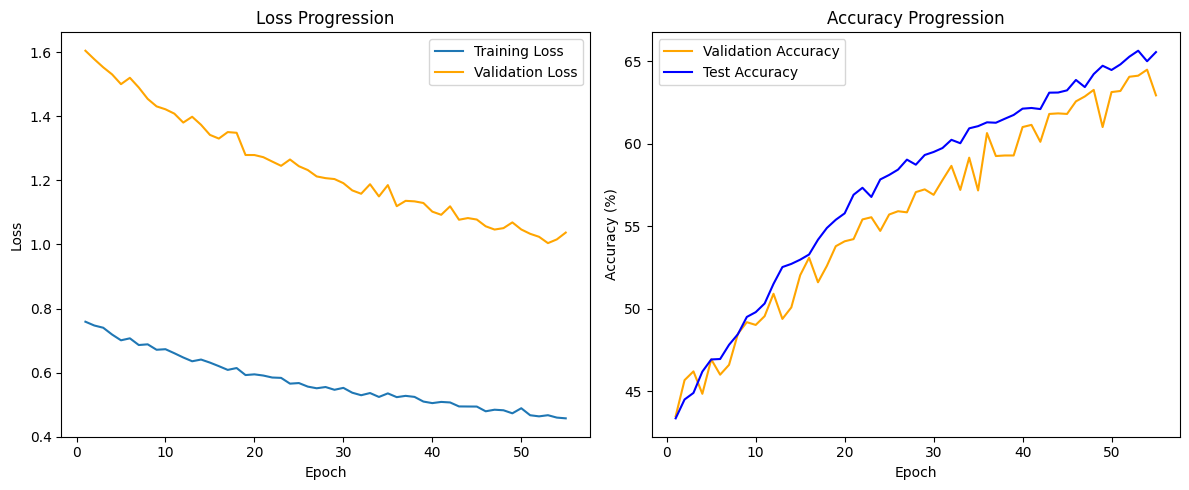

Epoch 56/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 56, Batch 100] loss: 0.977
Accuracy after epoch 56: 63.75%


Epoch 57/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 57, Batch 100] loss: 0.955
Accuracy after epoch 57: 64.68%


Epoch 58/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 58, Batch 100] loss: 0.953
Accuracy after epoch 58: 65.87%


Epoch 59/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 59, Batch 100] loss: 0.956
Accuracy after epoch 59: 65.37%


Epoch 60/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 60, Batch 100] loss: 0.930
Accuracy after epoch 60: 66.63%


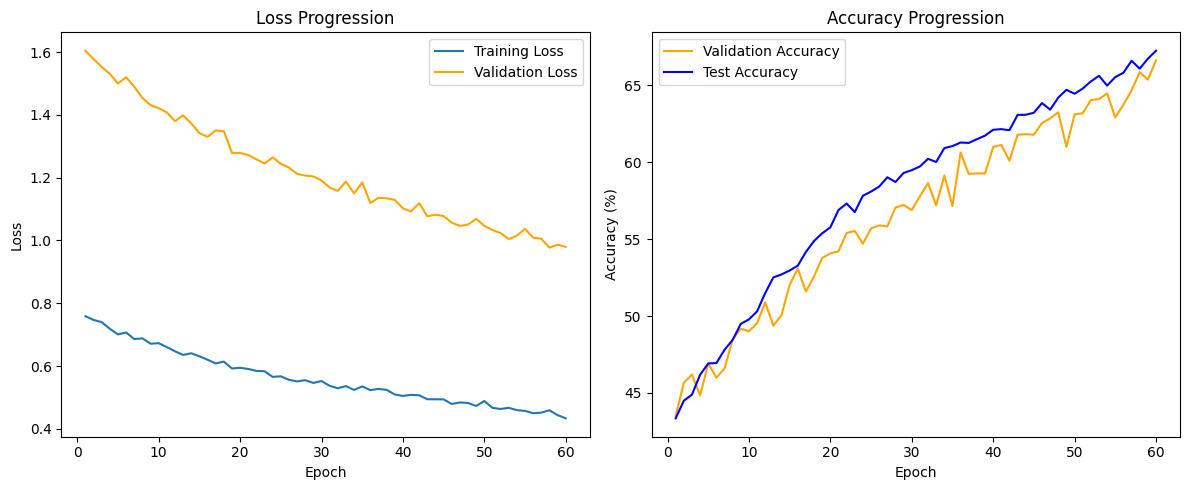

Epoch 61/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 61, Batch 100] loss: 0.945
Accuracy after epoch 61: 66.70%


Epoch 62/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 62, Batch 100] loss: 0.912
Accuracy after epoch 62: 65.08%


Epoch 63/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 63, Batch 100] loss: 0.911
Accuracy after epoch 63: 67.69%


Epoch 64/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 64, Batch 100] loss: 0.933
Accuracy after epoch 64: 65.51%


Epoch 65/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 65, Batch 100] loss: 0.882
Accuracy after epoch 65: 67.43%


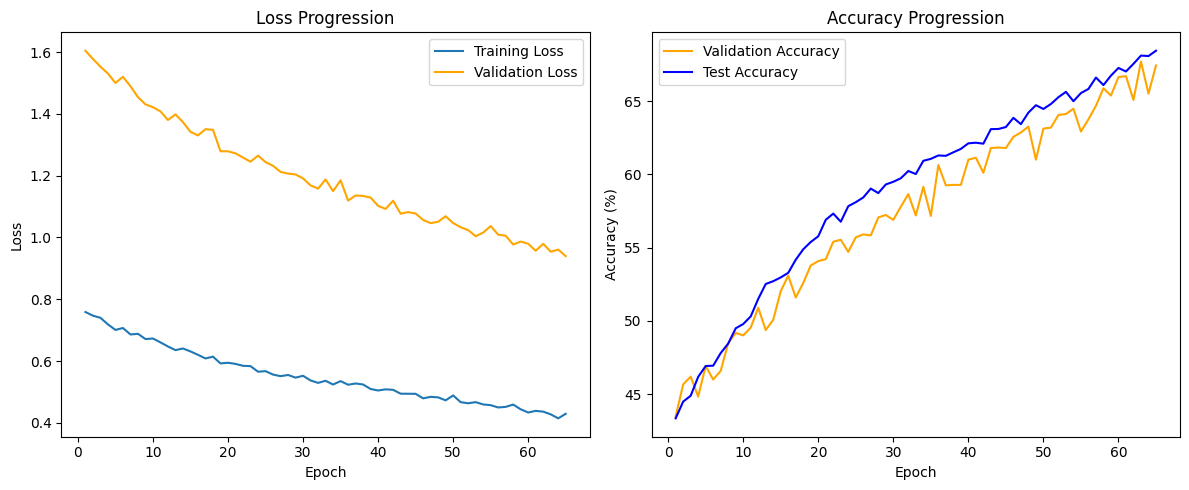

Epoch 66/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 66, Batch 100] loss: 0.891
Accuracy after epoch 66: 66.57%


Epoch 67/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 67, Batch 100] loss: 0.877
Accuracy after epoch 67: 66.93%


Epoch 68/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 68, Batch 100] loss: 0.866
Accuracy after epoch 68: 66.73%


Epoch 69/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 69, Batch 100] loss: 0.873
Accuracy after epoch 69: 66.93%


Epoch 70/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 70, Batch 100] loss: 0.873
Accuracy after epoch 70: 67.53%


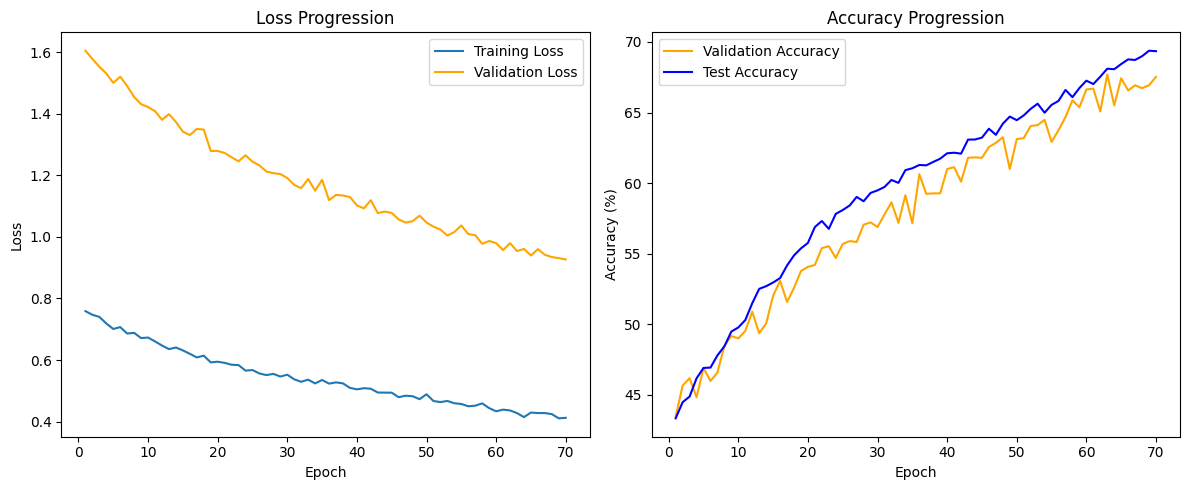

Epoch 71/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 71, Batch 100] loss: 0.869
Accuracy after epoch 71: 66.73%


Epoch 72/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 72, Batch 100] loss: 0.866
Accuracy after epoch 72: 68.32%


Epoch 73/100:   0%|          | 0/189 [00:00<?, ?batch/s]

...

Epoch 74/100:   0%|          | 0/189 [00:00<?, ?batch/s]

Exception in thread Thread-9:
Traceback (most recent call last):
  File "C:\Users\david\AppData\Local\Programs\Python\Python310\lib\threading.py", line 1009, in _bootstrap_inner
    self.run()
  File "c:\Users\david\Desktop\Code\DNN\DNNvenv\lib\site-packages\tqdm\_monitor.py", line 69, in run
    instances = self.get_instances()
  File "c:\Users\david\Desktop\Code\DNN\DNNvenv\lib\site-packages\tqdm\_monitor.py", line 49, in get_instances
    return [i for i in self.tqdm_cls._instances.copy()
  File "C:\Users\david\AppData\Local\Programs\Python\Python310\lib\_weakrefset.py", line 97, in copy
    return self.__class__(self)
  File "C:\Users\david\AppData\Local\Programs\Python\Python310\lib\_weakrefset.py", line 51, in __init__
    self.update(data)
  File "C:\Users\david\AppData\Local\Programs\Python\Python310\lib\_weakrefset.py", line 124, in update
    for element in other:
  File "C:\Users\david\AppData\Local\Programs\Python\Python310\lib\_weakrefset.py", line 65, in __iter__
    for 

[Epoch 74, Batch 100] loss: 0.842
Accuracy after epoch 74: 68.26%


Epoch 75/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 75, Batch 100] loss: 0.835
Accuracy after epoch 75: 68.62%


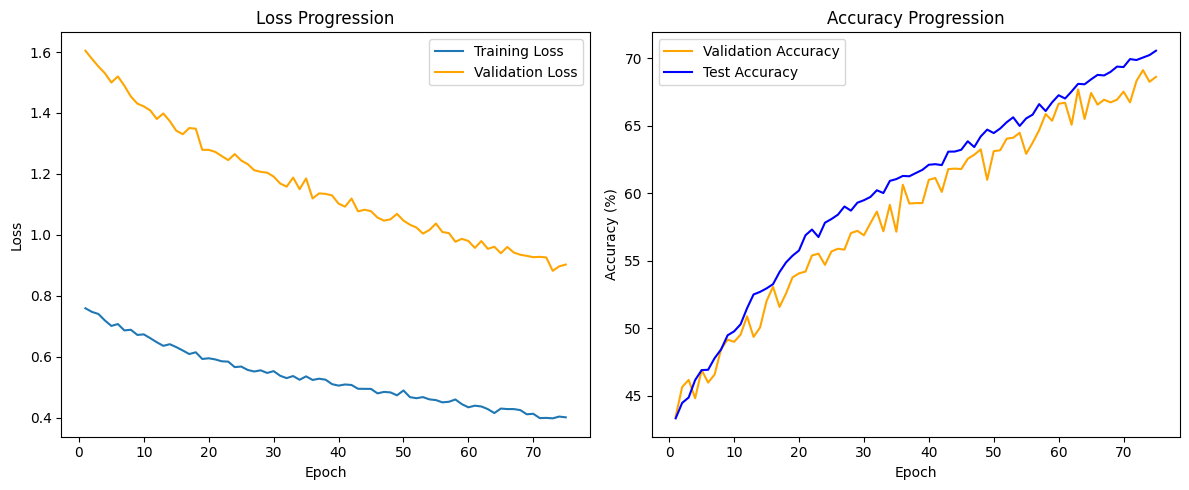

Epoch 76/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 76, Batch 100] loss: 0.835
Accuracy after epoch 76: 69.62%


Epoch 77/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 77, Batch 100] loss: 0.834
Accuracy after epoch 77: 68.36%


Epoch 78/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 78, Batch 100] loss: 0.812
Accuracy after epoch 78: 68.92%


Epoch 79/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 79, Batch 100] loss: 0.817
Accuracy after epoch 79: 69.95%


Epoch 80/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 80, Batch 100] loss: 0.824
Accuracy after epoch 80: 71.17%


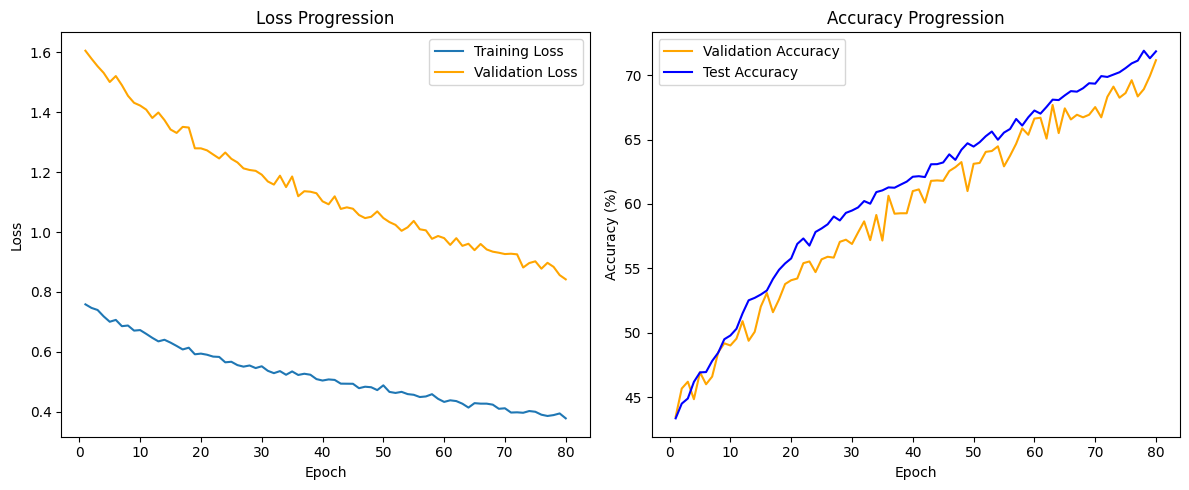

Epoch 81/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 81, Batch 100] loss: 0.795
Accuracy after epoch 81: 70.54%


Epoch 82/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 82, Batch 100] loss: 0.800
Accuracy after epoch 82: 70.54%


Epoch 83/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 83, Batch 100] loss: 0.823
Accuracy after epoch 83: 69.88%


Epoch 84/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 84, Batch 100] loss: 0.808
Accuracy after epoch 84: 70.81%


Epoch 85/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 85, Batch 100] loss: 0.789
Accuracy after epoch 85: 70.68%


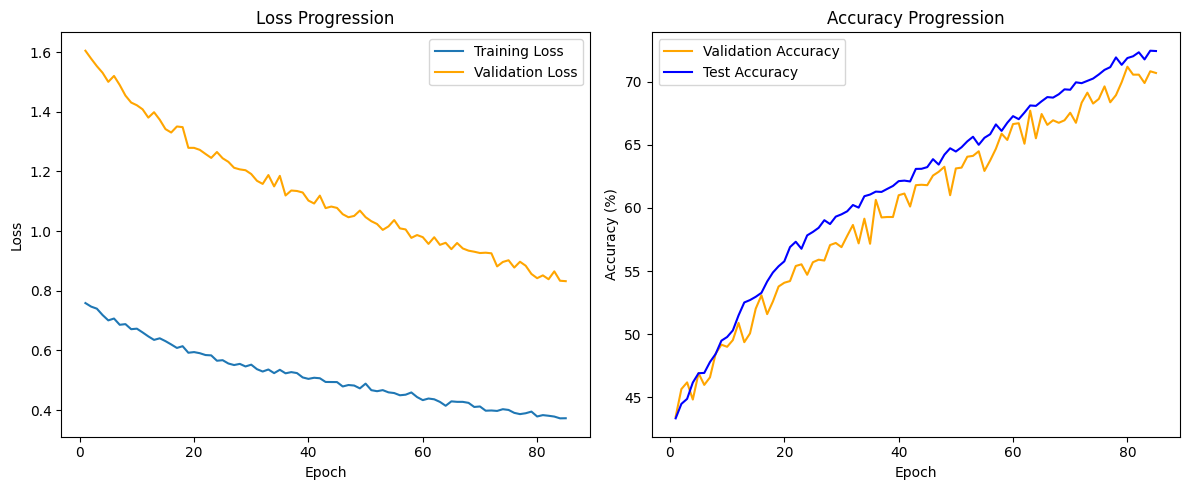

Epoch 86/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 86, Batch 100] loss: 0.779
Accuracy after epoch 86: 70.51%


Epoch 87/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 87, Batch 100] loss: 0.792
Accuracy after epoch 87: 70.05%


Epoch 88/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 88, Batch 100] loss: 0.781
Accuracy after epoch 88: 71.74%


Epoch 89/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 89, Batch 100] loss: 0.760
Accuracy after epoch 89: 68.16%


Epoch 90/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 90, Batch 100] loss: 0.761
Accuracy after epoch 90: 70.94%


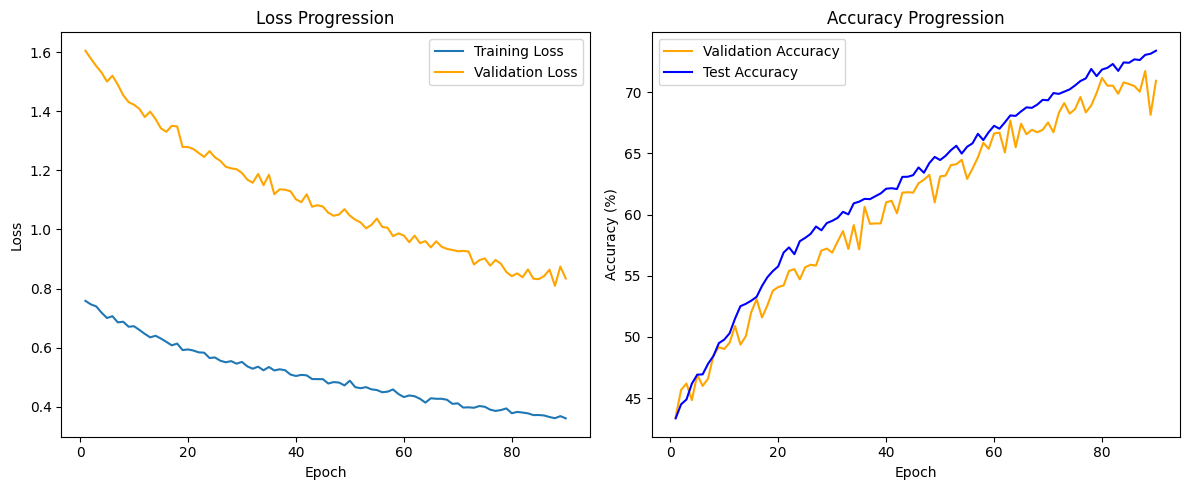

Epoch 91/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 91, Batch 100] loss: 0.772
Accuracy after epoch 91: 72.93%


Epoch 92/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 92, Batch 100] loss: 0.758
Accuracy after epoch 92: 71.04%


Epoch 93/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 93, Batch 100] loss: 0.761
Accuracy after epoch 93: 71.57%


Epoch 94/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 94, Batch 100] loss: 0.734
Accuracy after epoch 94: 71.60%


Epoch 95/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 95, Batch 100] loss: 0.748
Accuracy after epoch 95: 70.61%


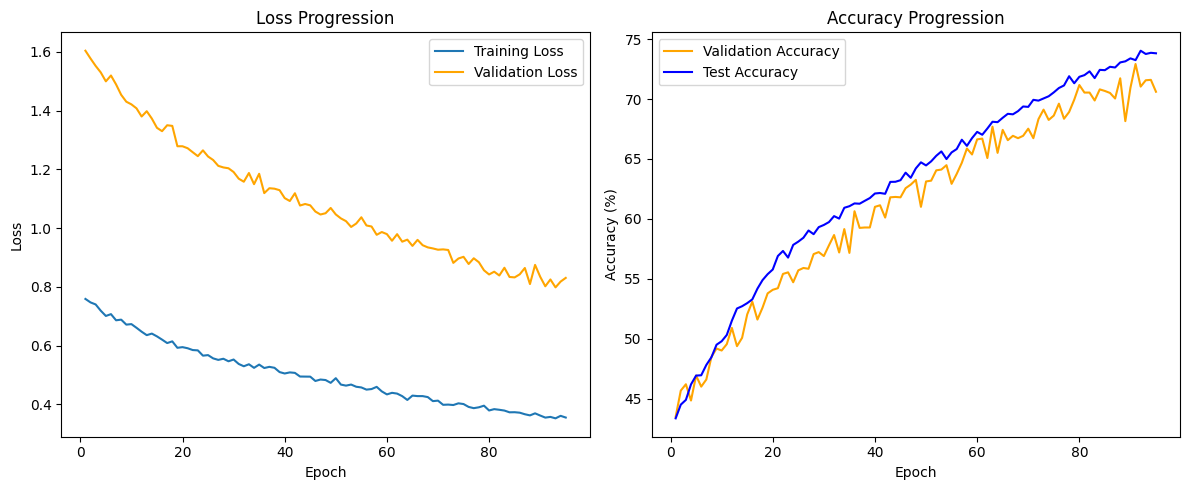

Epoch 96/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 96, Batch 100] loss: 0.734
Accuracy after epoch 96: 71.77%


Epoch 97/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 97, Batch 100] loss: 0.710
Accuracy after epoch 97: 72.07%


Epoch 98/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 98, Batch 100] loss: 0.731
Accuracy after epoch 98: 70.18%


Epoch 99/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 99, Batch 100] loss: 0.738
Accuracy after epoch 99: 71.17%


Epoch 100/100:   0%|          | 0/189 [00:00<?, ?batch/s]

[Epoch 100, Batch 100] loss: 0.733
Accuracy after epoch 100: 72.83%


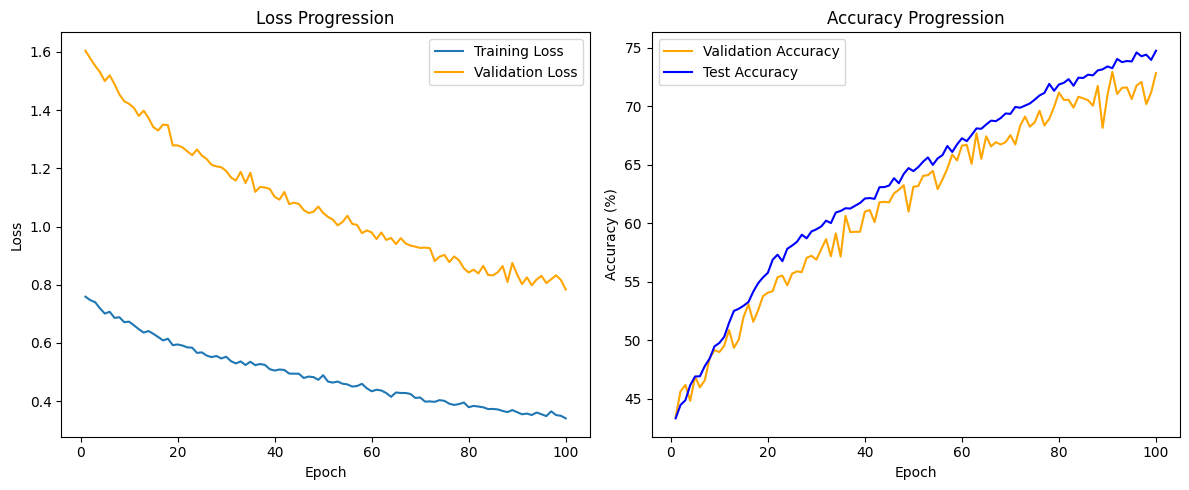

Finished Training


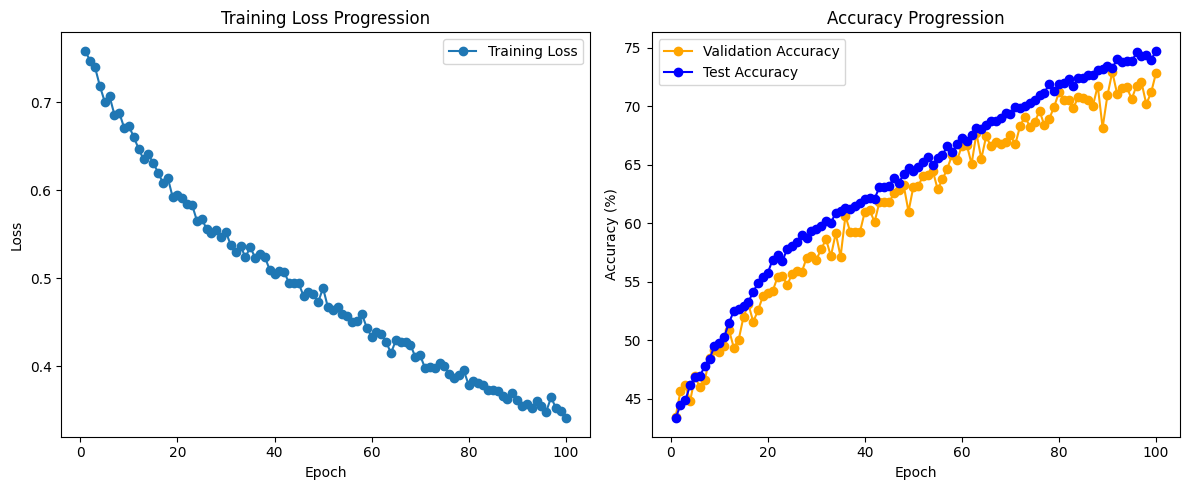

In [19]:
# Define the number of epochs
num_epochs = 100
model.to(device)
# Lists to store loss and accuracy
train_losses = []
val_losses = []  
val_accuracies = []
acc_history = []
model.train()  # Set the model to training mode
# Training loop
for epoch in range(num_epochs):
    correct = 0
    total = 0
    running_loss = 0.0
    progress_bar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    
    # Mini-batch training
    for i, data in enumerate(trainloader, 0):
        # Get inputs and labels
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Accumulate the running loss
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)  # Get the predicted class (index of max log-probability)
        total += labels.size(0)  # Total number of labels in this mini-batch
        correct += (predicted == labels).sum().item()  # Compare predictions to true labels and count correct ones

        # Print loss every 100 mini-batches
        if i % 100 == 99:  
            print(f"[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}")
            running_loss = 0.0
    epoch_accuracy = 100 * correct / total  # Compute accuracy percentage
    acc_history.append(epoch_accuracy)
    # After each epoch, save the average training loss
    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    # Validation accuracy check
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    val_running_loss = 0.0 
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_running_loss / len(testloader)
    val_losses.append(avg_val_loss)
    # Calculate and store validation accuracy
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)
    print(f"Accuracy after epoch {epoch + 1}: {val_accuracy:.2f}%")
    if (epoch+1) % 5 == 0:
        plotGraphs(epoch)

print('Finished Training')

# Plot training loss and validation accuracy
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot 
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.title('Training Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='o', color='orange')
plt.plot(epochs, acc_history, label='Test Accuracy', marker='o', color='blue')
plt.title('Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
def plotGraphs(num_epochsIn):
    epochs = range(1, num_epochsIn + 2)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange')
    plt.title('Loss Progression')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='orange')
    plt.plot(epochs, acc_history, label='Test Accuracy', color='blue')
    plt.title('Accuracy Progression')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

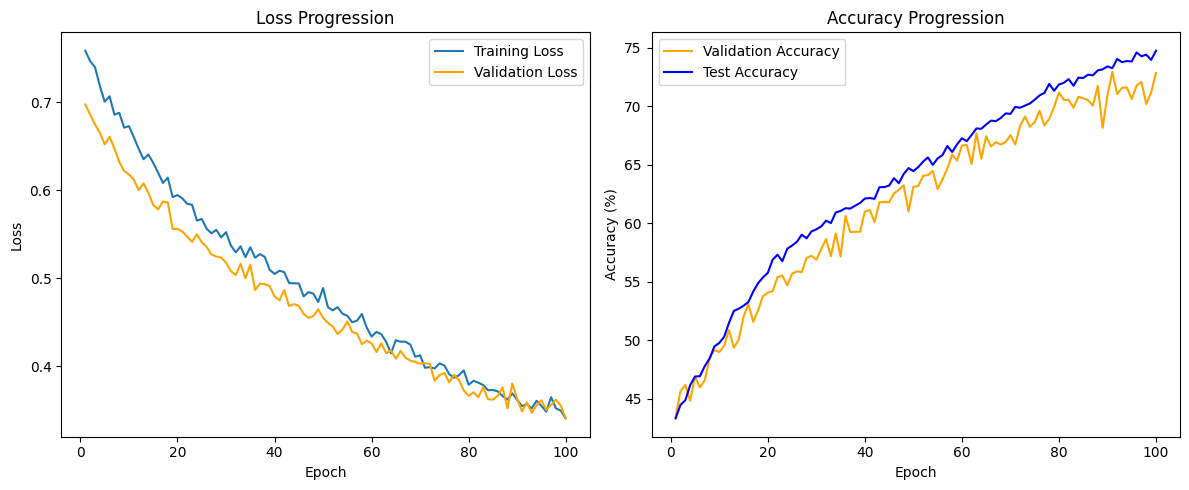

In [30]:
epochs = range(1, num_epochs +1)
val_losses1 = [num /2.3  for num in val_losses]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses1, label='Validation Loss', color='orange')
plt.title('Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='orange')
plt.plot(epochs, acc_history, label='Test Accuracy', color='blue')
plt.title('Accuracy Progression')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

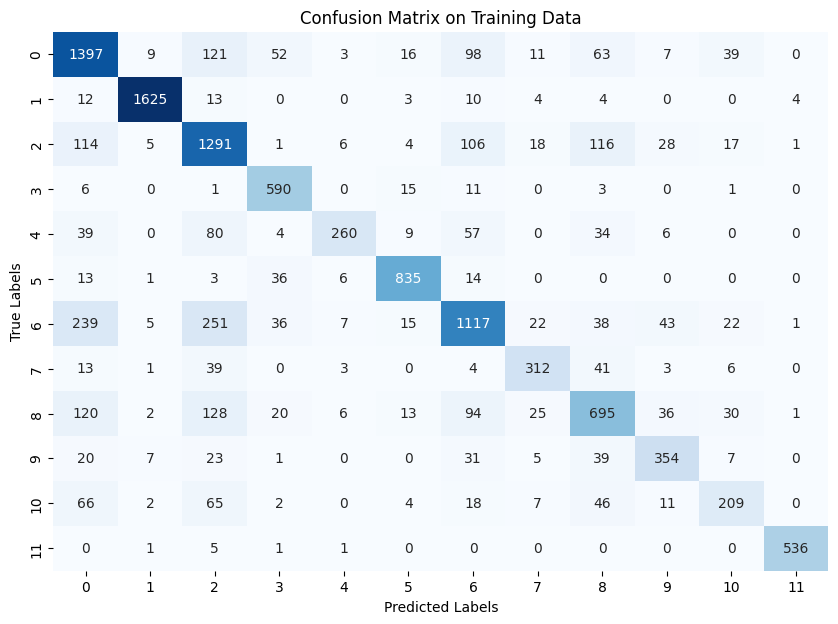

In [20]:
model.eval()  

all_preds = []
all_labels = []

with torch.no_grad():  
    for data in trainloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  
        
        all_preds.extend(predicted.cpu().numpy())  
        all_labels.extend(labels.cpu().numpy()) 

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix on Training Data")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

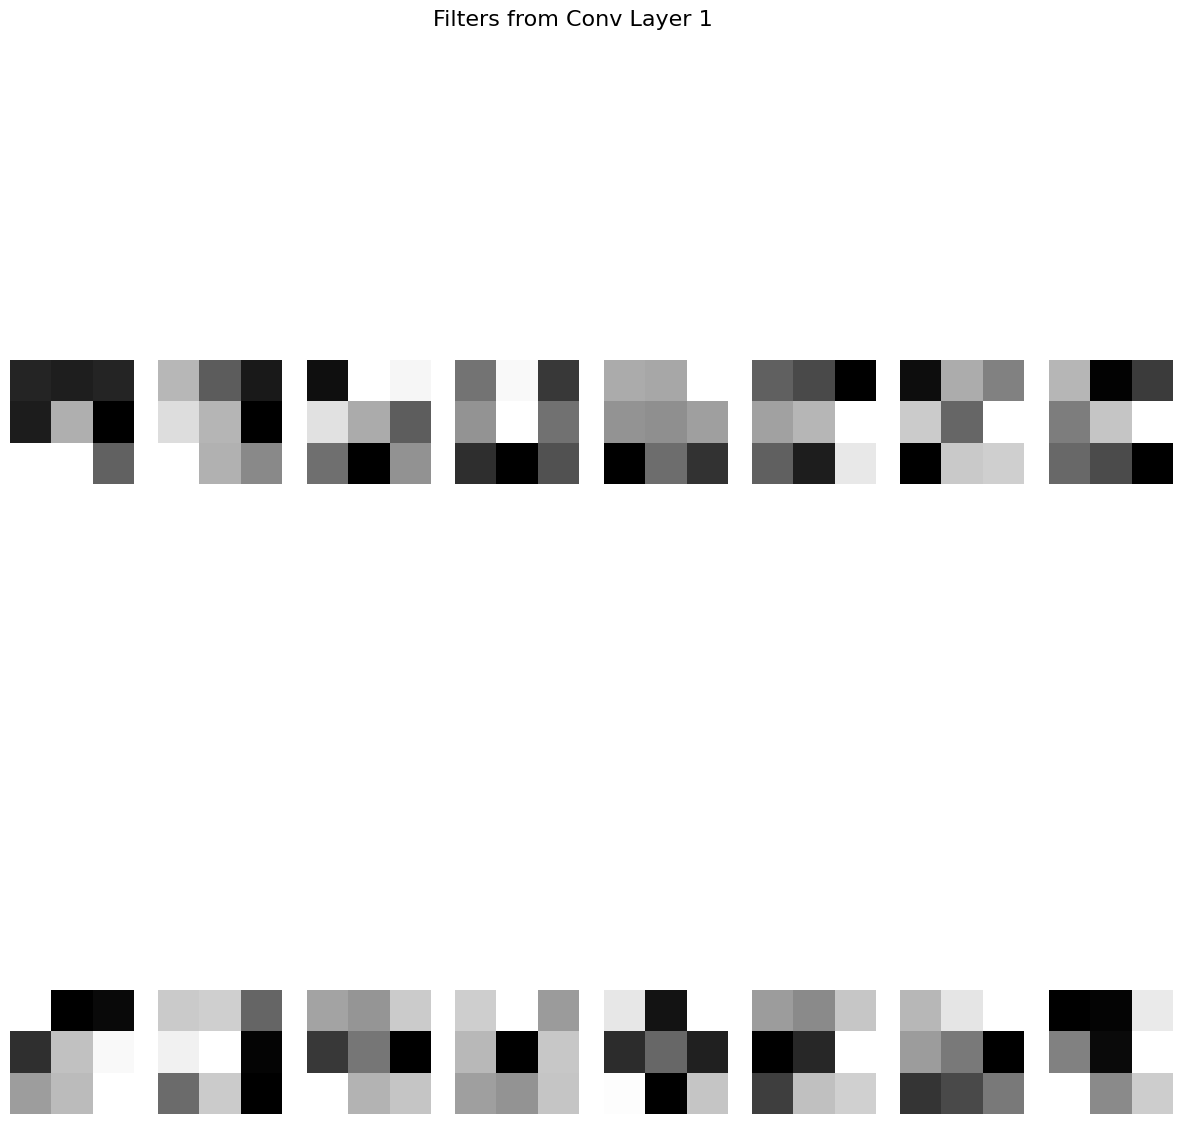

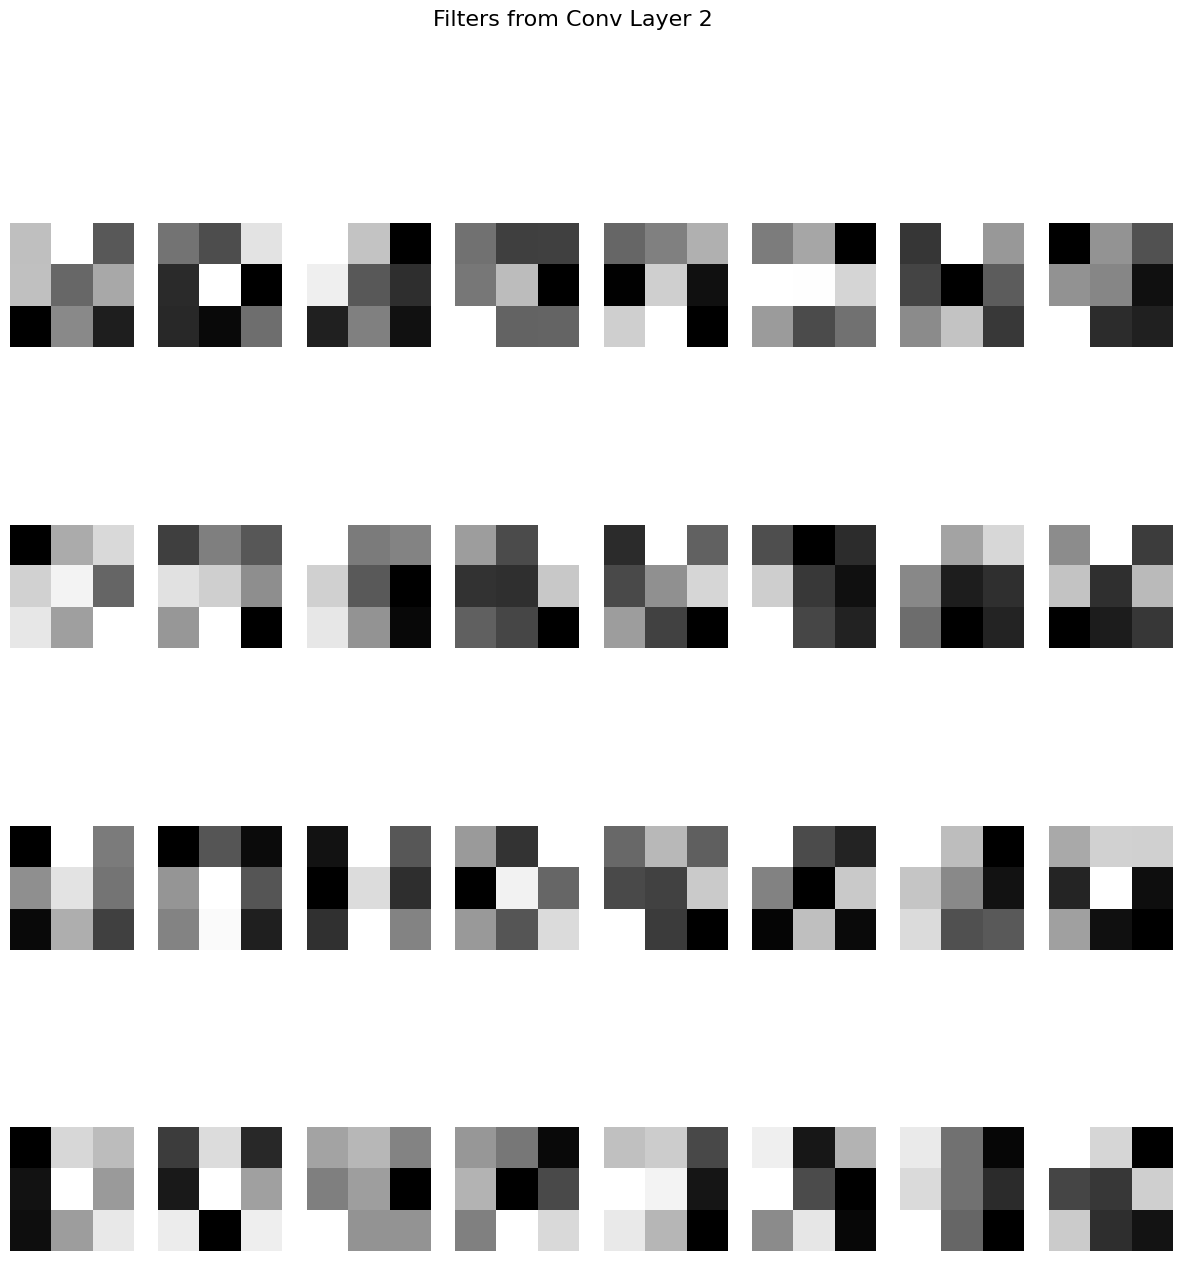

In [32]:
import math
def visualize_filters(model):
    conv_layer_count = 0  # Track the convolutional layer count
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layer_count += 1

            if conv_layer_count == 1:
                filters = module.weight.data.cpu()
                filters = (filters - filters.min()) / (filters.max() - filters.min())  # Normalize

                num_filters = filters.shape[0]
                num_cols = 8  
                num_rows = math.ceil(num_filters / num_cols)

                fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15))

                for i in range(num_filters):
                    row = i // num_cols
                    col = i % num_cols
                    axs[row, col].imshow(filters[i, 0, :, :], cmap='gray')
                    axs[row, col].axis('off')

                for j in range(i + 1, num_rows * num_cols):
                    fig.delaxes(axs[j // num_cols, j % num_cols])

                plt.suptitle("Filters from Conv Layer 1", fontsize=16)
                plt.show()

            if conv_layer_count == 2:
                filters = module.weight.data.cpu()
                filters = (filters - filters.min()) / (filters.max() - filters.min())  # Normalize

                num_filters = filters.shape[0]
                num_cols = 8  
                num_rows = math.ceil(num_filters / num_cols)

                fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15))

                for i in range(num_filters):
                    row = i // num_cols
                    col = i % num_cols
                    axs[row, col].imshow(filters[i, 0, :, :], cmap='gray')
                    axs[row, col].axis('off')

                for j in range(i + 1, num_rows * num_cols):
                    fig.delaxes(axs[j // num_cols, j % num_cols])

                plt.suptitle("Filters from Conv Layer 2", fontsize=16)
                plt.show()
                break  
 

visualize_filters(model)

Feature maps for layer: branch1_conv1


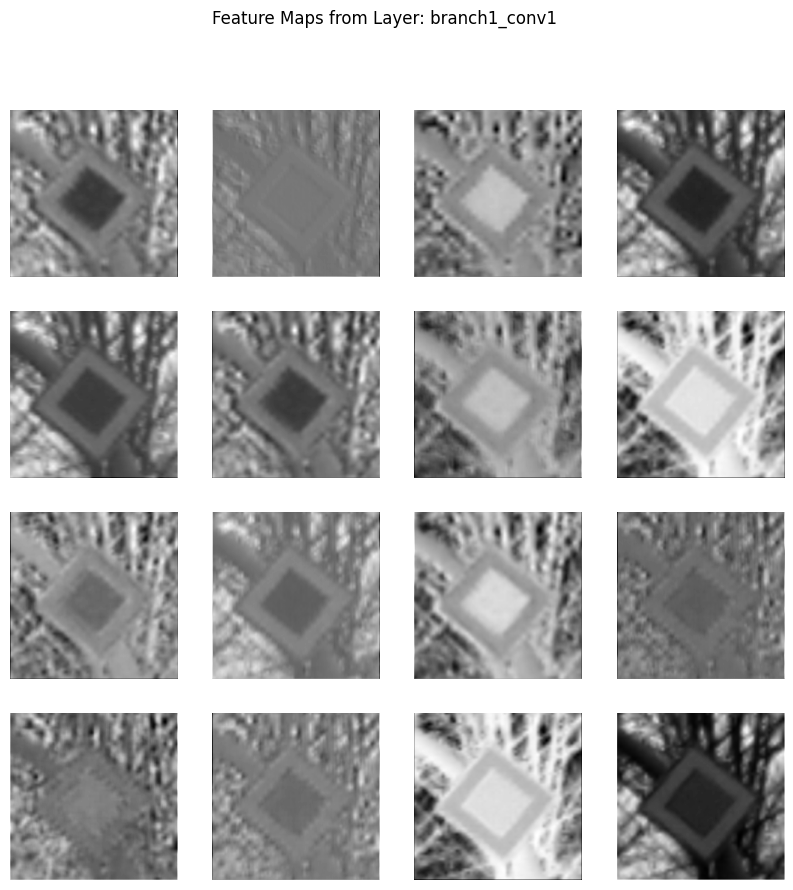

Feature maps for layer: branch1_conv2


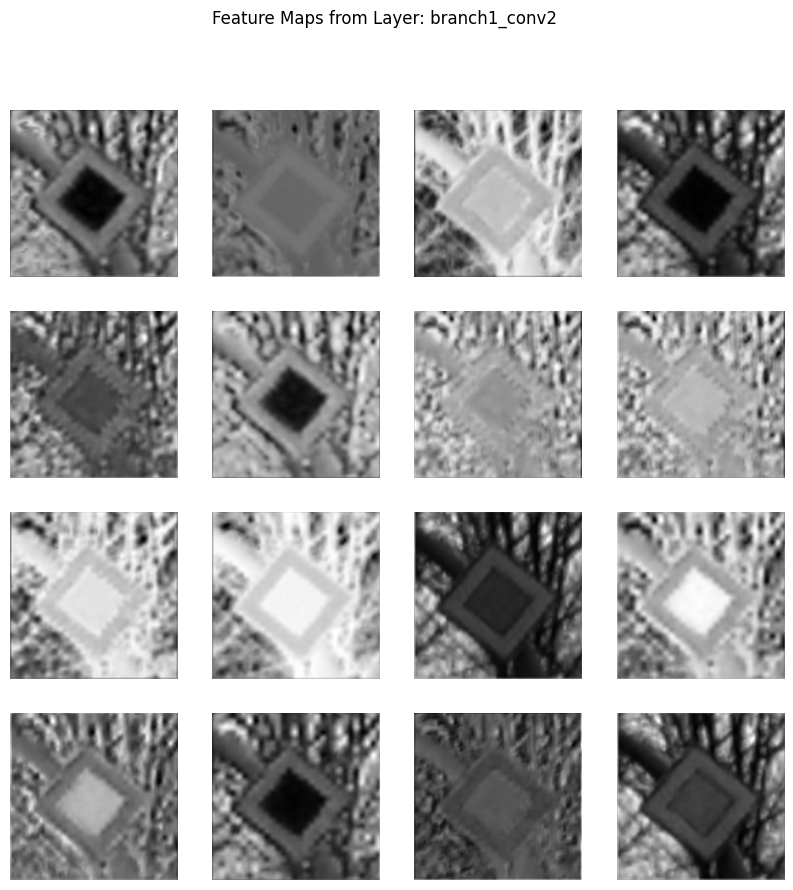

Feature maps for layer: branch2_conv1


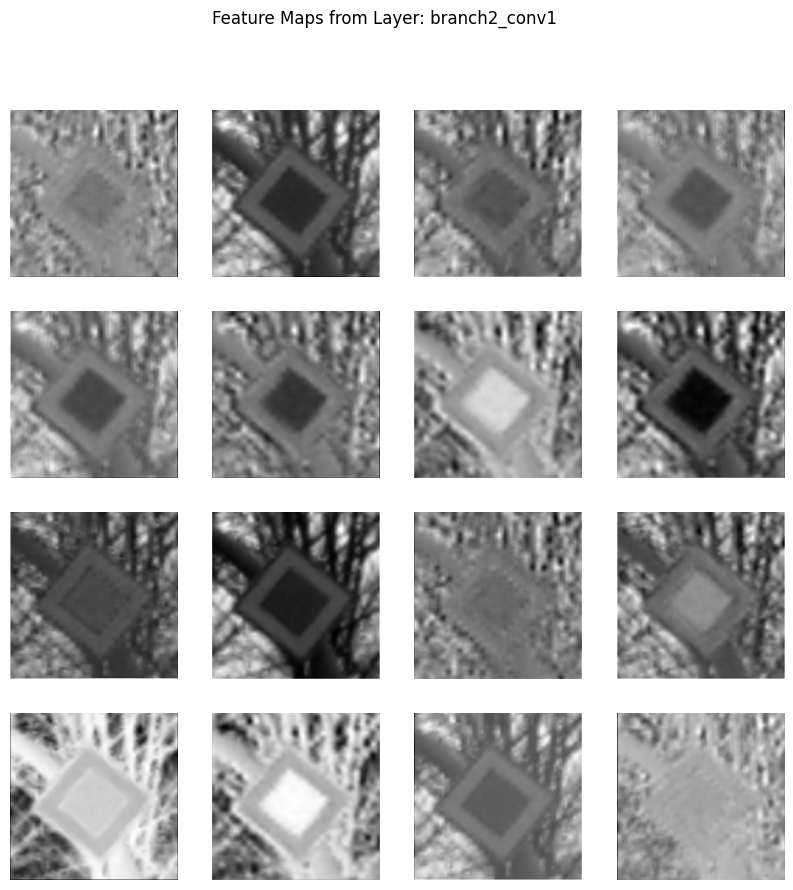

Feature maps for layer: branch2_conv2


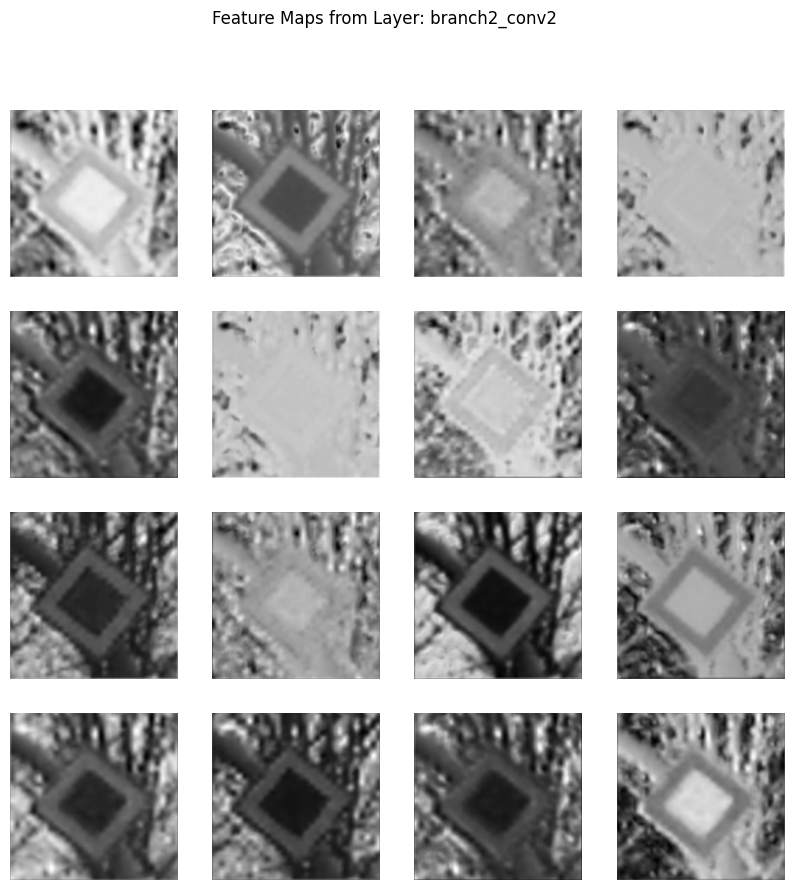

In [33]:
def visualize_feature_maps(model, image):
    activation = {}

    # Hook to store activations
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()  # Detach to prevent tracking gradients
        return hook

    # Register hooks for all convolutional layers in the model
    for name, layer in model.named_modules():
        if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
            layer.register_forward_hook(get_activation(name))

    # Perform a forward pass with the provided image
    with torch.no_grad():  # Disable gradient computation
        _ = model(image)

    # Visualize the feature maps
    for name, features in activation.items():
        if isinstance(features, torch.Tensor):
            print(f"Feature maps for layer: {name}")
            feature_num = features.shape[1]

            # Plotting limits
            num_plots = min(feature_num, 16)  # Only plot up to 16 feature maps
            plt.figure(figsize=(10, 10))  # Set a figure size

            for i in range(num_plots):
                plt.subplot(4, 4, i + 1)
                plt.imshow(features[0, i, :, :].cpu().numpy(), cmap='gray')
                plt.axis('off')

            plt.suptitle(f"Feature Maps from Layer: {name}")  # Title for clarity
            plt.show()

# Prepare the input image
inp, _ = train_dataset.__getitem__(0)  # Get the first item from the dataset
inp = inp.unsqueeze(0)  # Add batch dimension (1, channels, height, width)

# Call the function to visualize feature maps
visualize_feature_maps(model.to(device), inp.to(device)) 